In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds  
import numpy as np
import matplotlib.pyplot as plt 

print("TensorFlow version:",tf.__version__)

TensorFlow version: 2.21.0


In [5]:
(ds_train,ds_test),ds_info = tfds.load(
    'emnist/balanced',
    split=['train','test'],
    shuffle_files=True,
    as_supervised=True,
    with_info = True
)

print(ds_info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\HP\tensorflow_datasets\emnist\balanced\incomplete.48M6BT_3.1.0\emnist-train.tfrecord-[0-9][…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\HP\tensorflow_datasets\emnist\balanced\incomplete.48M6BT_3.1.0\emnist-test.tfrecord-[0-9][0…

Dataset emnist downloaded and prepared to C:\Users\HP\tensorflow_datasets\emnist\balanced\3.1.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='emnist',
    full_name='emnist/balanced/3.1.0',
    description="""
    The EMNIST dataset is a set of handwritten character digits derived from the NIST Special Database 19 and converted to a 28x28 pixel image format and dataset structure that directly matches the MNIST dataset.
    
    Note: Like the original EMNIST data, images provided here are inverted horizontally and rotated 90 anti-clockwise. You can use `tf.transpose` within `ds.map` to convert the images to a human-friendlier format.
    """,
    config_description="""
    EMNIST Balanced
    """,
    homepage='https://www.nist.gov/itl/products-and-services/emnist-dataset',
    data_dir='C:\\Users\\HP\\tensorflow_datasets\\emnist\\balanced\\3.1.0',
    file_format=tfrecord,
    download_size=535.73 MiB,
    dataset_size=56.63 MiB,
    features=FeaturesDict({


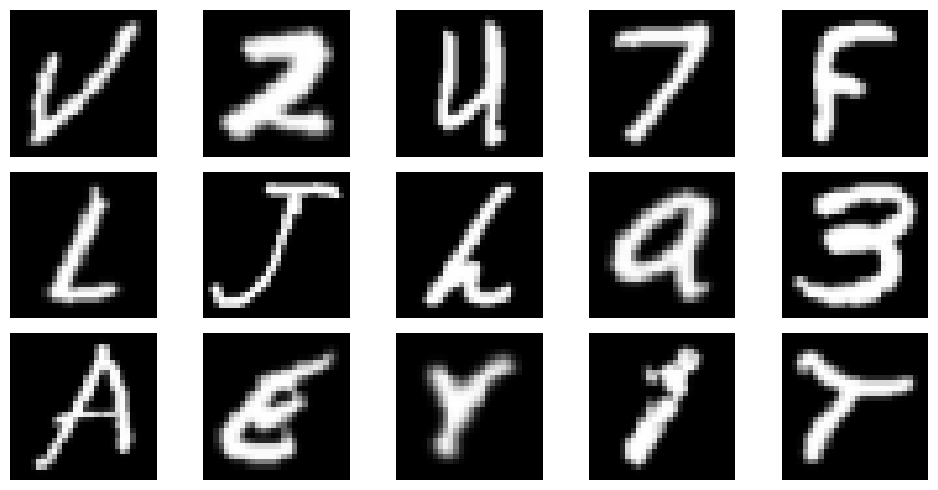

In [10]:
def fix_orientation(image, label):
    image = tf.transpose(image,perm=[1,0,2])
    return image, label

ds_train_fixed = ds_train.map(fix_orientation)

plt.figure(figsize = (10,5))
for i, (image,label) in enumerate(ds_train_fixed.take(15)):
    plt.subplot(3,5,i+1)
    plt.imshow(image.numpy().squeeze(),cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()    

In [ ]:
class_names = list("0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt")

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 47
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']


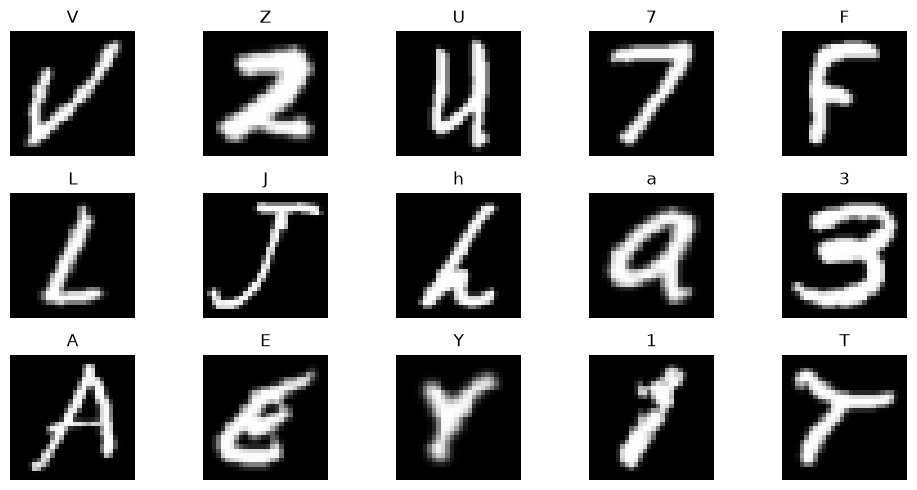

In [14]:
plt.figure(figsize = (10,5))
for i, (image,label) in enumerate(ds_train_fixed.take(15)):
    plt.subplot(3,5,i+1)
    plt.imshow(image.numpy().squeeze(),cmap='gray')
    plt.title(f"{class_names[label.numpy()]}")
    plt.axis('off')
plt.tight_layout()
plt.show()   

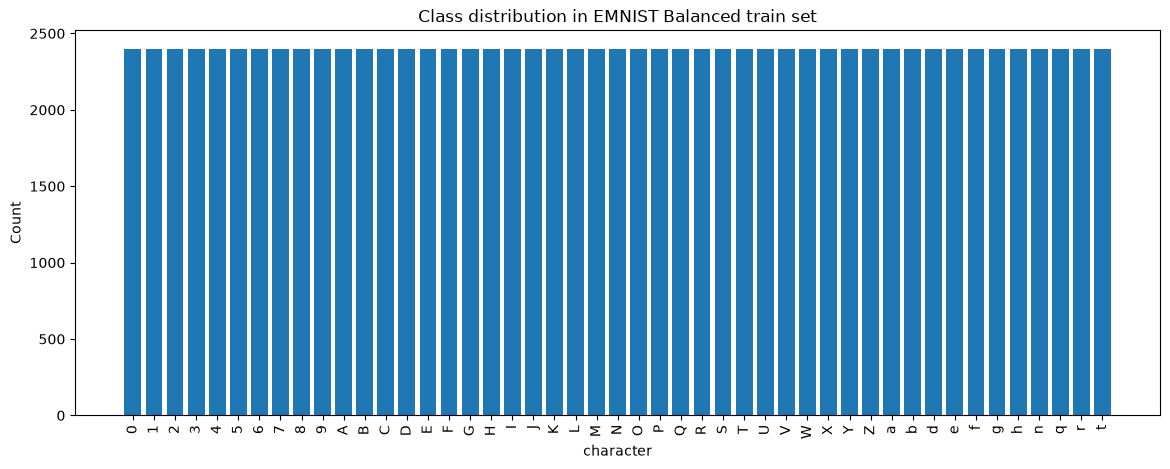

Min count: 2400 | Max count: 2400


In [20]:
labels_list = []
for _,label in ds_train:
    labels_list.append(label.numpy())
    
labels_array = np.array(labels_list)
unique , counts = np.unique(labels_array,return_counts=True)

plt.figure(figsize=(14,5))
plt.bar([class_names[u] for u in unique], counts)
plt.xlabel("character")
plt.ylabel("Count")
plt.title("Class distribution in EMNIST Balanced train set")
plt.xticks(rotation=90)
plt.show()

print("Min count:", counts.min(), "| Max count:", counts.max())

In [34]:
def preprocess(image,label):
    image = tf.transpose(image,perm=[1,0,2])
    image = tf.cast(image,tf.float32) / 255.0
    return image, label

BATCH_SIZE = 128

train_data = (
    ds_train
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_data = (
    ds_test
    .map(preprocess,num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for images, labels in train_data.take(1):
    print ("Batch image shape: ",images.shape)
    print("Batch label shape: ", labels.shape)
    print("Pixel value range: ", images.numpy().min()," - ",images.numpy().max())    

Batch image shape:  (128, 28, 28, 1)
Batch label shape:  (128,)
Pixel value range:  0.0  -  1.0


In [40]:
from tensorflow.keras import layers , models

num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(28,28,1)),
    
    layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes,activation = 'softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics= ['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 47)             │        12,079 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 400,815 (1.53 MB)

 Trainable params: 400,367 (1.53 MB)

 Non-trainable params: 448 (1.75 KB)

In [45]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
882/882 ━━━━━━━━━━━━━━━━━━━━ 96s 109ms/step - accuracy: 0.9212 - loss: 0.1924 - val_accuracy: 0.8867 - val_loss: 0.4003
Epoch 2/10
882/882 ━━━━━━━━━━━━━━━━━━━━ 99s 112ms/step - accuracy: 0.9233 - loss: 0.1845 - val_accuracy: 0.8885 - val_loss: 0.4050
Epoch 3/10
882/882 ━━━━━━━━━━━━━━━━━━━━ 101s 114ms/step - accuracy: 0.9255 - loss: 0.1809 - val_accuracy: 0.8874 - val_loss: 0.4233
Epoch 4/10
882/882 ━━━━━━━━━━━━━━━━━━━━ 99s 112ms/step - accuracy: 0.9294 - loss: 0.1725 - val_accuracy: 0.8869 - val_loss: 0.4220
Epoch 5/10
882/882 ━━━━━━━━━━━━━━━━━━━━ 98s 111ms/step - accuracy: 0.9299 - loss: 0.1687 - val_accuracy: 0.8857 - val_loss: 0.4162
Epoch 6/10
882/882 ━━━━━━━━━━━━━━━━━━━━ 99s 112ms/step - accuracy: 0.9313 - loss: 0.1642 - val_accuracy: 0.8846 - val_loss: 0.4320
Epoch 7/10
882/882 ━━━━━━━━━━━━━━━━━━━━ 109s 124ms/step - accuracy: 0.9330 - loss: 0.1604 - val_accuracy: 0.8869 - val_loss: 0.4245
Epoch 8/10
882/882 ━━━━━━━━━━━━━━━━━━━━ 105s 119ms/step - accuracy: 0.9353 - loss

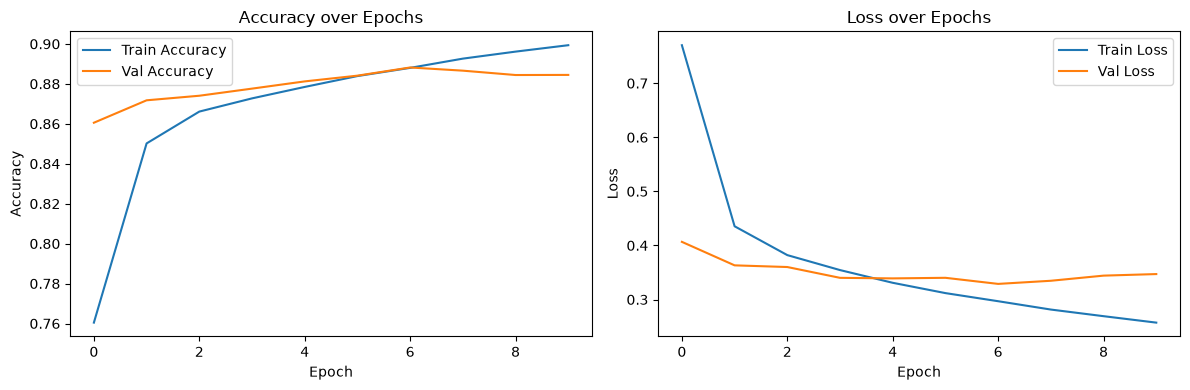

In [42]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.tight_layout()
plt.show()

In [43]:
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

147/147 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.8845 - loss: 0.3470
Test Accuracy: 0.8845
Test Loss: 0.3470
